In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("banknotes.csv")
df

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [9]:
df.isnull().sum()

Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

In [10]:
#check for pattern through viz


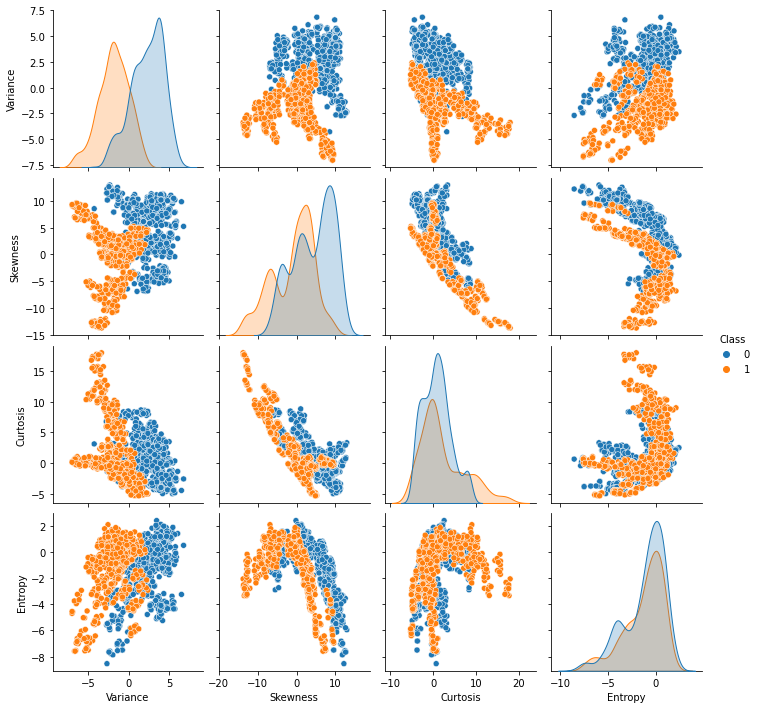

In [18]:
sns.pairplot(df,hue = "Class");

In [19]:
#check the distribution of target variable(countplot)

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Class', ylabel='count'>

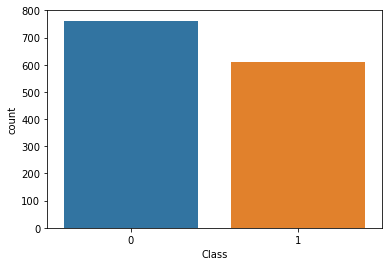

In [24]:
sns.countplot(df["Class"])

In [26]:
x = df.drop("Class",axis =1)
y = df["Class"]

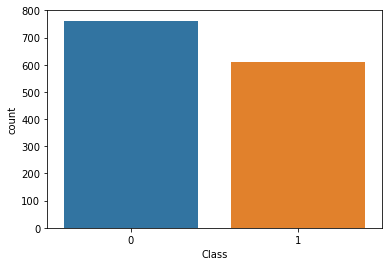

In [27]:
sns.countplot(x=y);

In [64]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
X = df[['Variance','Skewness','Curtosis','Entropy']]
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25, random_state=0)

model = LogisticRegression(max_iter=1000)
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.99514563 0.97572816 0.98058252 1.         1.        ]
Average Accuracy: 0.9902912621359224


In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25, random_state=0)


In [34]:
X_train.shape,y_train.shape

((1029, 4), (1029,))

In [35]:
#build the decision Tree
# and also evaluate

In [37]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [38]:
#evaluate

In [39]:
y_pred = dt.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9825072886297376

In [41]:
x.columns

Index(['Variance', 'Skewness', 'Curtosis', 'Entropy'], dtype='object')

In [42]:
dt.feature_importances_

array([0.5977114 , 0.2153741 , 0.15161006, 0.03530443])

In [43]:
#plot the graph to viz feature importance

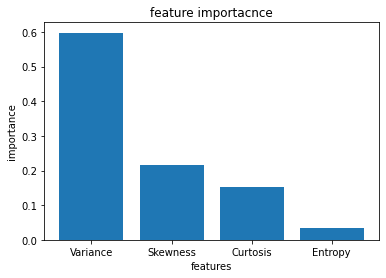

In [48]:
plt.title("feature importacnce")
plt.xlabel("features")
plt.ylabel("importance")
plt.bar(x.columns , dt.feature_importances_);

In [49]:
#plot tree

In [50]:
from sklearn.tree import plot_tree


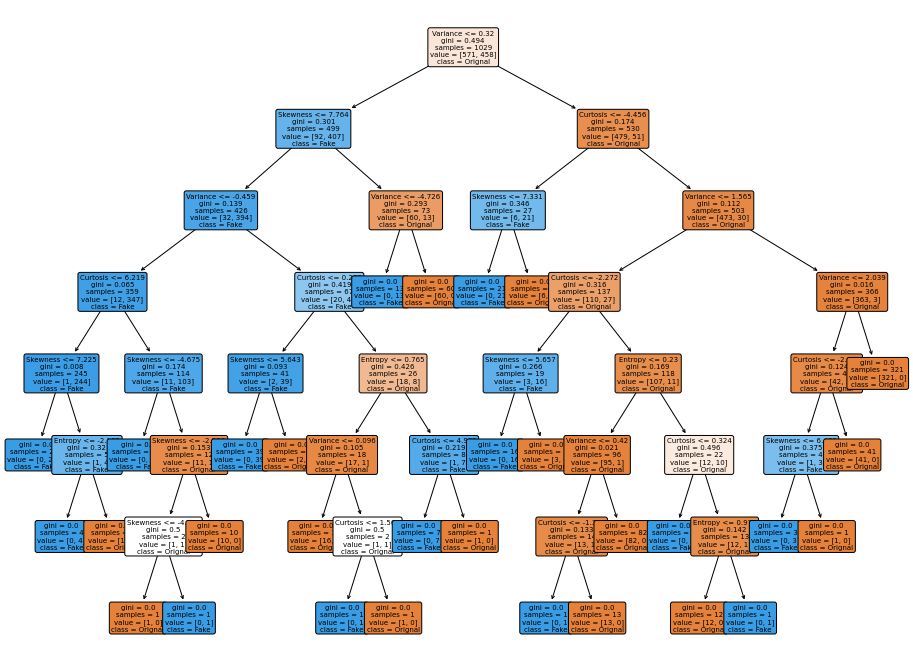

In [55]:
plt.figure(figsize =(16,12))
plot_tree(dt,rounded=True,fontsize=7,filled = True,
         class_names=['Orignal','Fake'],
         feature_names=x.columns);

In [54]:
"""
4.86600
-163830
0.9242
0.645
""";

In [59]:
new = [[4.86600,
-163830,
0.9242,
0.645]]

In [60]:
dt.predict(new)

array([0], dtype=int64)